# CNN for Gaussian noise plus random vertical or horizontal lines classification

- Generate 1x30x30 images with Gaussian noise, perfectly vertical or horizontal lines of different brights located at random poistions (see 5:32, lecture 193)
- Create train/dev/test sets
- Create CNN mnodel to classify images beeing either vertical or horizontal

# Implementation

In [1]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

# model summary info
from torchsummary import summary

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
# use GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Generate Dataset

data.shape: torch.Size([100000, 1, 30, 30])
labels.shape: torch.Size([100000, 1])
Min: 0.0  Max: 1.0


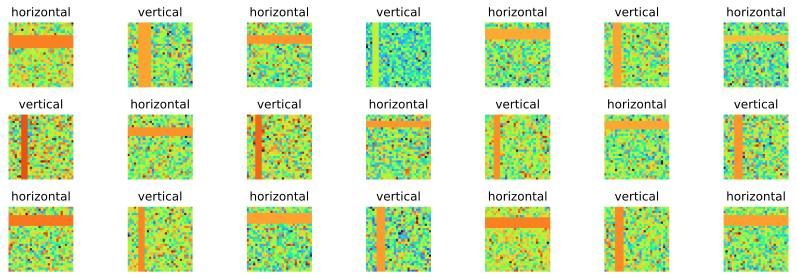

In [121]:
class DatasetGenerator:
    def __init__(self,
                 shape:tuple[int,int]=(30,30),
                 mu:float=0.5,
                 sigma:float=0.2,
                 random_state:int=-1):
        self.shape = shape
        self.mu = mu
        self.sigma = sigma
        if random_state > 0:
            self.rng = np.random.default_rng(random_state)
        else:
            self.rng = np.random.default_rng()
        self.classes_ = {0: 'horizontal', 1: 'vertical'}

    def generate(self, n_samples:int=3):
        X = torch.zeros((n_samples, 1, *self.shape), dtype=torch.float32)
        y = torch.zeros((n_samples,1), dtype=torch.float32)
        random_pos = [
            self.rng.integers(self.shape[0]//10, self.shape[0]//4, size=n_samples),
            self.rng.integers(self.shape[1]//10, self.shape[1]//4, size=n_samples),
        ]
        min_shape_val = min(self.shape)
        width_range = (max(1,int(0.1*min_shape_val)), int(0.2*min_shape_val) + 1)
        random_width = self.rng.integers(width_range[0], width_range[1], size=n_samples)
        line_pix_val = self.mu + 1.5*self.sigma  # make line pixel value distinct
        for i in range(n_samples):
            X[i] = torch.Tensor(self.rng.normal(self.mu, self.sigma, self.shape)).float()
            # add the line
            w = random_width[i]
            pos = random_pos[i%2][i]
            if i%2 == 1:
                X[i][0,:,pos:pos+w] = line_pix_val  # vertical line
                y[i] = 1  # (0 - horizontal, 1 - vertical)
            else:
                X[i][0,pos:pos+w,:] = line_pix_val  # horizontal line
            X[i] = (X[i] - X[i].min()) / (X[i].max() - X[i].min()) # normalize to [0,1]
        return X, y
    
    def classes(self):
        return self.classes_

dgen = DatasetGenerator(mu=0.5, sigma=0.1)
data, labels = dgen.generate(n_samples=100000)
print('data.shape:', data.shape)
print('labels.shape:', labels.shape)
print(f'Min: {data.min()}  Max: {data.max()}')
W = 7
H = 3
fig, axs = plt.subplots(H,W,figsize=(12,4))
for i in range(W*H):
    axs.flatten()[i].imshow(data[i,0],cmap='turbo')
    axs.flatten()[i].set_title(dgen.classes()[labels[i].item()])

for a in axs.flatten():
    a.set_axis_off()
    
fig.tight_layout()
plt.show()

# Split dataset into train/dev/test

In [122]:
# use scikitlearn to split the data
train_data,test_data, train_labels,test_labels = train_test_split(data, labels, test_size=.1)

test_data,dev_data, test_labels,dev_labels = train_test_split(test_data, test_labels, test_size=.5)

# convert into PyTorch Datasets
train_set = TensorDataset(train_data, train_labels)
test_set  = TensorDataset(test_data, test_labels)
dev_set = TensorDataset(dev_data, dev_labels)

# translate into dataloader objects
batchsize    = 500
train_loader = DataLoader(train_set,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_set,batch_size=test_set.tensors[0].shape[0],shuffle=True)
dev_loader   = DataLoader(dev_set,batch_size=dev_set.tensors[0].shape[0],shuffle=True)

In [123]:
# check size (should be images X channels X width X height
print( train_loader.dataset.tensors[0].shape )
print( train_loader.dataset.tensors[1].shape )

print( test_loader.dataset.tensors[0].shape )
print( test_loader.dataset.tensors[1].shape )

print( dev_loader.dataset.tensors[0].shape )
print( dev_loader.dataset.tensors[1].shape )

torch.Size([90000, 1, 30, 30])
torch.Size([90000, 1])
torch.Size([5000, 1, 30, 30])
torch.Size([5000, 1])
torch.Size([5000, 1, 30, 30])
torch.Size([5000, 1])


# Create CNN Model

In [ ]:
# create a class for the model
def makeTheNet(lr:float=.001,printtoggle:bool=False):

  class linenet(nn.Module):
    def __init__(self, printtoggle):
        super().__init__()
        
        self.print = printtoggle
        self.inSize = 30
        self.p2d_ksz = 2  # kernel size for maxpool2d
        self.p2d_strd = 2 # stride for maxpool2d
        self.p_drop = .2
      
        # For equation see: https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
        CNNLayerOutSize = lambda in_dim, conv, pooling: \
            int(np.ceil((in_dim + 2*conv.padding[0] - conv.kernel_size[0])//conv.stride[0] + 1)//pooling)
        
        self.conv1  = nn.Conv2d(1,8,3,padding=1)
        self.bn1 = nn.BatchNorm2d(self.conv1.out_channels)
        nOutCNNLayer1 = CNNLayerOutSize(self.inSize, self.conv1, self.p2d_ksz)
        if self.print: print(f'\nnOutCNNLayer1: {nOutCNNLayer1}')
        
        # Flat layers:
        self.fc1 = nn.Linear(nOutCNNLayer1*nOutCNNLayer1*self.conv1.out_channels, 32)
        self.bn_fc1 = nn.BatchNorm1d(self.fc1.out_features)

        self.fc_out = nn.Linear(self.fc1.out_features, 1)

    def forward(self,x):
        if self.print: print(f'\nInput: {list(x.shape)}')
        
        # Conv layers:
        x = self.conv1(x)
        x = F.max_pool2d(x, kernel_size=self.p2d_ksz)
        x = F.relu(x)
        x = self.bn1(x)
        if self.print: print(f'conv1 out shape: {list(x.shape)}')
        
        # Vectroize conv output:
        x = x.flatten(start_dim=1)
        if self.print: print(f'Vectorized: {list(x.shape)}')
        
        # Flat layers:
        x = self.fc1(x)
        x = F.relu(x)
        x = self.bn_fc1(x)
        x = F.dropout(x, p=self.p_drop, training=self.training)
        if self.print: print(f'fc1 out shape: {list(x.shape)}')
        
        x = self.fc_out(x)
        # x = F.softmax(x, dim=1)
        if self.print: print(f'fc out shape: {list(x.shape)}\n')
        
        return x
  
    @staticmethod
    def accuracy(yHat, y):
        return torch.mean(((yHat > .5).float().detach() == y).float()).item()

  net = linenet(printtoggle=printtoggle)
  lossfun = nn.BCEWithLogitsLoss()
  optimizer = torch.optim.Adam(net.parameters(),lr=lr)

  return net,lossfun,optimizer

# test the model with one batch
net,lossfun,optimizer = makeTheNet(printtoggle=True)

X,y = next(iter(train_loader))
yHat = net(X)

# check size of output
print('y.shape: ', y.shape)
print('yHat.shape: ', yHat.shape)

# # now let's compute the loss
loss = lossfun(yHat,y)
print('\nLoss:', loss.item())
print('Accuracy:', net.accuracy(yHat,y))

summary(net,(1,30,30), device='cpu')


nOutCNNLayer1: 15

Input: [500, 1, 30, 30]
conv1 out shape: [500, 8, 15, 15]
Vectorized: [500, 1800]
fc1 out shape: [500, 32]
fc out shape: [500, 1]

y.shape:  torch.Size([500, 1])
yHat.shape:  torch.Size([500, 1])

Loss: 0.7610589861869812
Accuracy: 0.5479999780654907

Input: [2, 1, 30, 30]
conv1 out shape: [2, 8, 15, 15]
Vectorized: [2, 1800]
fc1 out shape: [2, 32]
fc out shape: [2, 1]

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 8, 30, 30]              80
       BatchNorm2d-2            [-1, 8, 15, 15]              16
            Linear-3                   [-1, 32]          57,632
       BatchNorm1d-4                   [-1, 32]              64
            Linear-5                    [-1, 1]              33
Total params: 57,825
Trainable params: 57,825
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
F

# Train the model

In [145]:
# a function that trains the model
def function2trainTheModel(train_loader, dev_loader, lr, numepochs:int=3):

  # create a new model
  net,lossfun,optimizer = makeTheNet(lr=lr)

  # send the model to the GPU
  net.to(device)

  # initialize losses
  trainLoss = torch.zeros(numepochs)
  devLoss  = torch.zeros(numepochs)
  trainAcc  = torch.zeros(numepochs)
  devAcc   = torch.zeros(numepochs)

  # loop over epochs
  for epochi in range(numepochs):
    net.train()

    # loop over training data batches
    batchLoss = []
    batchAcc  = []
    
    for batchi,(X,y) in enumerate(train_loader):

      # push data to GPU
      X = X.to(device)
      y = y.to(device)

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss and error from this batch
      batchLoss.append(loss.item())
      batchAcc.append(net.accuracy(yHat,y))
    # end of batch loop...

    # and get average losses and error rates across the batches
    trainLoss[epochi] = np.mean(batchLoss)
    trainAcc[epochi]  = 100*np.mean(batchAcc)

    ### dev performance
    net.eval()
    X,y = next(iter(dev_loader))
    X = X.to(device)
    y = y.to(device)
    with torch.no_grad(): # deactivates autograd
      yHat = net(X)
      loss = lossfun(yHat,y.float())
    devLoss[epochi] = loss.item()
    devAcc[epochi] = 100*net.accuracy(yHat,y)

    print(f'epoch {epochi+1}/{numepochs}: '
          f'train loss: {trainLoss[epochi]:.4f} '
          f'dev loss: {devLoss[epochi]:.4f} '
          f'train acc: {trainAcc[epochi]:.2f}% '
          f'dev acc: {devAcc[epochi]:.2f}%', end='\r' )

  # end epochs
  
  net.eval() # set model to eval mode as done training

  # function output
  return trainLoss,devLoss,trainAcc,devAcc,net

In [146]:
trainLoss,devLoss,trainAcc,devAcc,net = function2trainTheModel(train_loader, dev_loader, lr=.001, numepochs=10)

In [147]:
# Run on test_set
X_test,y_test = next(iter(test_loader))
X_test = X_test.to(device)
y_test = y_test.to(device)

print('X_test.shape:', X_test.shape)
print('y_test.shape:', y_test.shape)

with torch.no_grad():
    yHat_test = net(X_test).cpu().detach()
X_test = X_test.cpu().detach().to(torch.float32)
y_test = y_test.cpu().detach()

testLoss = lossfun(yHat_test,y_test).item()
testAcc  = 100*net.accuracy(yHat_test,y_test)

print('testLoss:', testLoss)
print('testAcc:', testAcc)

X_test.shape: torch.Size([5000, 1, 30, 30])
y_test.shape: torch.Size([5000, 1])
testLoss: 7.502351945731789e-05
testAcc: 100.0


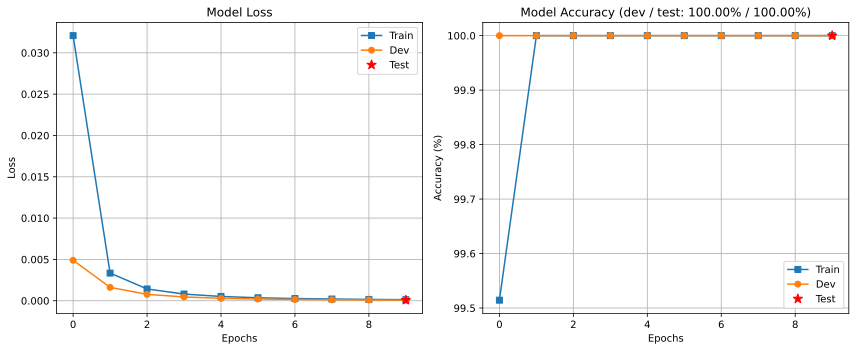

In [148]:
fig,axs = plt.subplots(1,2,figsize=(12,5))

axs[0].plot(trainLoss,'s-',label='Train')
axs[0].plot(devLoss,'o-',label='Dev')
axs[0].plot(len(trainLoss)-1, testLoss,'r*',markersize=10, label='Test')
axs[0].set_ylabel('Loss')
axs[0].set_title(f'Model Loss')

axs[1].plot(trainAcc,'s-',label='Train')
axs[1].plot(devAcc,'o-',label='Dev')
axs[1].plot(len(trainAcc)-1, testAcc,'r*',markersize=10, label='Test')
axs[1].set_ylabel('Accuracy (%)')
axs[1].set_title(f'Model Accuracy (dev / test: {devAcc[-1]:.2f}% / {testAcc:.2f}%)')

for a in axs.flatten():
    a.grid(True)
    a.legend()
    a.set_xlabel('Epochs')

fig.tight_layout()
plt.show()

X_test.shape[0]: 5000


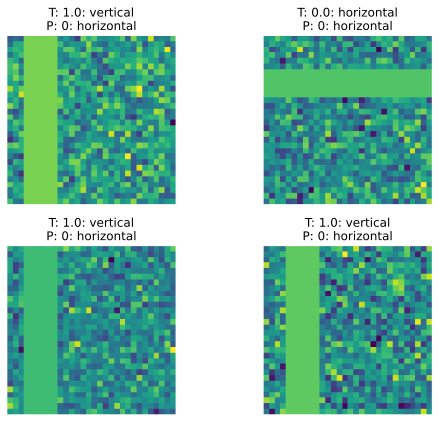

In [149]:
# Show some sample images
fig = plt.figure(figsize=(8,6))

W, H = 2, 2
print('X_test.shape[0]:', X_test.shape[0])
random_indexes = np.random.choice(X_test.shape[0], W*H, replace=False)
for idx, i in enumerate(random_indexes):
    ax = fig.add_subplot(H,W,idx+1)
    ax.imshow(X_test[i].cpu().numpy().transpose(1, 2, 0))  # transpose to HWC for display
    ax.set_title(f'T: {y_test[i].item()}: {dgen.classes()[y_test[i].item()]}\n'
                 f'P: {torch.argmax(yHat_test[i]).item()}: {dgen.classes()[torch.argmax(yHat_test[i]).item()]}')
    ax.axis('off')
fig.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

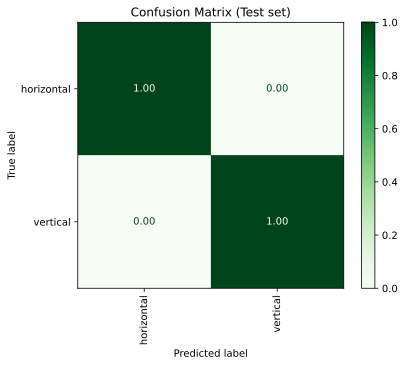

In [155]:
# Show confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig = plt.figure(figsize=(10,10))
cm_display = ConfusionMatrixDisplay.from_predictions(y_test.cpu().numpy(), (yHat_test > .5).float().cpu().numpy(),
                                                    display_labels=[dgen.classes()[i] for i in range(len(dgen.classes()))],
                                                    cmap=plt.cm.Greens,
                                                    xticks_rotation='vertical',
                                                    values_format='.2f',
                                                    normalize='true')
cm_display.ax_.set_title('Confusion Matrix (Test set)')

fig.tight_layout()
plt.show()

# The Images to Misclassify

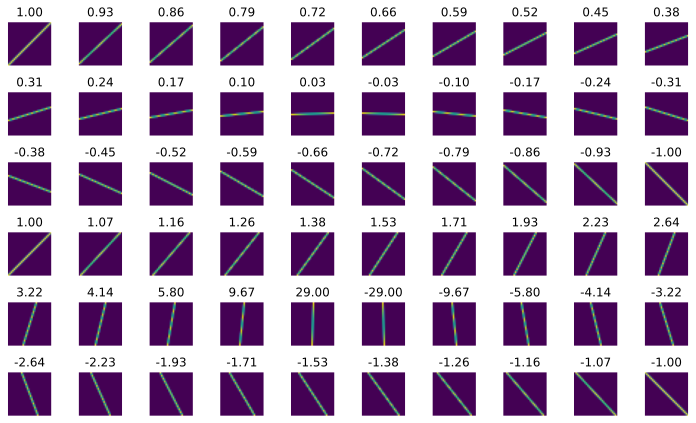

In [151]:
# Create images for the missclassification example
### create lines in images

from skimage.draw import line_aa

imgSize = 30
fig,ax = plt.subplots(6,10,figsize=(10,6))
imgs   = np.zeros((2*imgSize,1,imgSize,imgSize))
slopes = np.zeros(2*imgSize)

a = ax.flatten()
for i in range(imgSize):

  ### create lines with |slope|<1
  # point coords
  p1 = [0,i]
  p2 = [imgSize-p1[0]-1,imgSize-p1[1]-1]
  slopes[i] = (p2[1]-p1[1])/(p2[0]-p1[0]+1e-10)

  # create the lines
  rows,cols,val = line_aa(p1[1],p1[0],p2[1],p2[0]) #  y1,x1,y2,x2
  imgs[i,0,rows,cols] = val

  # plot
  a[i].imshow(imgs[i,0,:,:],origin='lower')
  a[i].set_title('%.2f'%slopes[i])
  a[i].axis('off')


  ### create lines with |slope|>1
  # point coords
  p1 = [i,0]
  p2 = [imgSize-p1[0]-1,imgSize-p1[1]-1]
  slopes[i+imgSize] = (p2[1]-p1[1])/(p2[0]-p1[0]+1e-10)

  # create the lines
  rows,cols,val = line_aa(p1[1],p1[0],p2[1],p2[0]) #  y1,x1,y2,x2
  imgs[i+imgSize,0,rows,cols] = val

  # plot
  a[i+imgSize].imshow(imgs[i+imgSize,0,:,:],origin='lower')
  a[i+imgSize].set_title('%.2f'%slopes[i+imgSize])
  a[i+imgSize].axis('off')

plt.tight_layout()
plt.show()

imgT.shape: torch.Size([60, 1, 30, 30])
yHat.shape: torch.Size([60, 1])


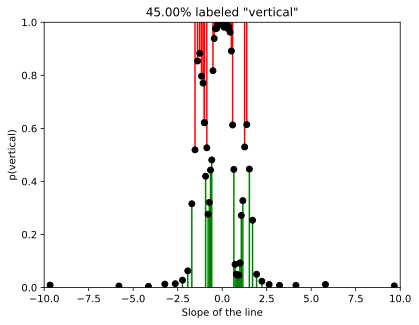

In [152]:
# run the images through the model

# randomly shuffle the images, just to be on the safe side...
# and also convert to tensor...
ridx = np.random.permutation(range(imgs.shape[0]))
imgT = torch.tensor(imgs[ridx,:,:,:].astype(np.float32)).to(device)
print('imgT.shape:', imgT.shape)


# now generate the prediction (horizontal or vertical)
net.eval()
yHat = torch.sigmoid( net(imgT) ).detach().cpu()
print('yHat.shape:', yHat.shape)

# plot the results (make sure the slopes use the same randomization)
for i in range(len(slopes)):
  if yHat[i] > .5:
    plt.plot([slopes[ridx[i]],slopes[ridx[i]]],[1,yHat[i].item()],'r')
  else:
    plt.plot([slopes[ridx[i]],slopes[ridx[i]]],[0,yHat[i].item()],'g')

plt.plot(slopes[ridx],yHat,'ko')
plt.xlabel('Slope of the line')
plt.ylabel('p(vertical)')
plt.title('%.2f%% labeled "vertical"' %torch.mean(100*(yHat>.5).float()).item())
plt.ylim([0,1])
plt.xlim([-10,10]) # note: this actually clips two data points
plt.show()

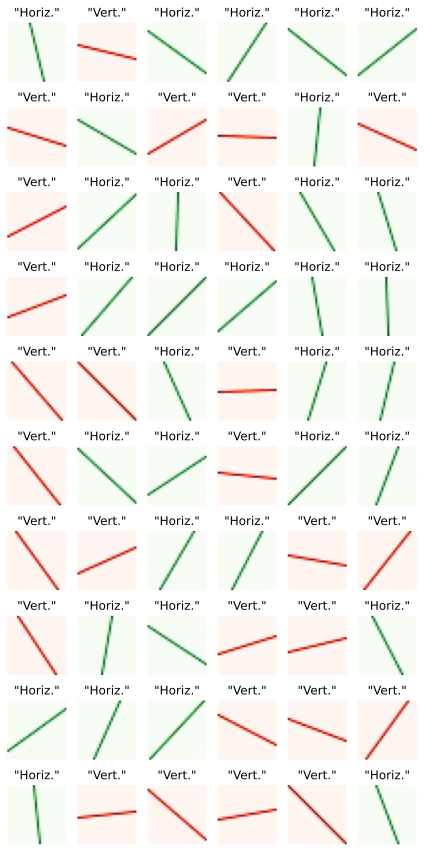

In [153]:
fig,ax = plt.subplots(10,6,figsize=(6,12))

for i,a in enumerate(ax.flatten()):

  # show the line-image (make sure to use the randomization index)
  if yHat[i]>.5:
    a.imshow(imgs[ridx[i],0,:,:],origin='lower',cmap='Reds')
  else:
    a.imshow(imgs[ridx[i],0,:,:],origin='lower',cmap='Greens')

  # and the title
  title = '"Vert."' if yHat[i].detach()>.5 else '"Horiz."'
  a.set_title(title)
  a.axis('off')

plt.tight_layout()
plt.show()